<a href="https://colab.research.google.com/github/flatwaze/vae-wgan-audio/blob/main/vae_gan_audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###VAE-WGAN + Hifi-GAN генерация коротких аудиофрагментов.

Цель данного проекта разработать генеративную модель, способную восстанавливать короткие аудиофрагменты произносимых цифр с минимальными искажениями и артефактами. Особое внимание уделяется сохранению гармонической структуры речи, что является важным аспектом имитации естественного звучания речи. В качестве источника данных используется простой датасет AudioMNIST, содержащий записи произнесённых цифр разными спикерами.

Архитектура объединяет в себе несколько последовательных этапов:
1. VAE (10 эпох, batch_size=128)
2. WGAN-GP fine-tune (10 эпох, batch_size=128)
3. Hifi-GAN vocoder pre-trained: https://huggingface.co/speechbrain/tts-hifigan-libritts-16kHz

На этапах 1-2 архитектура направлена на генерацию мел-спектрограмм цифр из AudioMNIST с последующим синтезом аудио через HiFi-GAN.
В качестве основы используется VAE: encoder/decoder обучаются с VAE-loss, получаемые спектрограммы обладают излишней сглаженностью, неприемлемой для текущей задачи. Поэтому VAE скорее служит фундаментом для стабильного обучения WGAN-GP: encoder/decoder выступают в роли генератора, а критик реализуется отдельной новой сетью.

Для декодера вместо ConvTranspose2d (порождающего шахматные артефакты при обучении WGAN) применяются Upsample + Conv. Однако такой подход может сохранять сглаженность очень продолжительное время. Для увеличения резкости вводится регуляризация на основе torch.diff + L1, также в WGAN-GP loss добавляется дополнительная регуляризация чистой реконструкции (MSE). После обучения сгенерированные спектрограммы подаются в предобученный HiFi-GAN вокодер, который формирует итоговый аудиосигнал.

**Важно отметить**, что поскольку предобученный HiFi-GAN ожидает на входе спектрограммы с фиксированными параметрами (частота дискретизации 16000 Гц, ..., подробнее см. документацию), была разработана некоторая процедура предобработки, чтобы обеспечить согласованность сгенерированных спектрограмм и ожидаемых предобученной моделью спектрограмм, это критически важно, потому что прямым образом влияет на результаты синтеза.

In [ ]:
!pip uninstall torchaudio -y
!pip install torchaudio==2.8.0

In [ ]:
!pip uninstall torch torchvision torchaudio torchmetrics -y
!pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 torchmetrics

In [ ]:
!pip install torch-fidelity

#### Imports

In [ ]:
import os
import random
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio
from IPython.display import clear_output
from pathlib import Path
from omegaconf import DictConfig

import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from tqdm.notebook import tqdm
from torch.utils.data import Subset, DataLoader
from torchaudio import transforms
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore", module="torchaudio._backend")



plt.rcParams.update({'font.size': 14})

In [ ]:
!git clone https://github.com/soerenab/AudioMNIST.git

In [ ]:
!pip install audiomentations
!pip install speechbrain

In [ ]:
!git lfs install

!git clone https://huggingface.co/speechbrain/tts-hifigan-libritts-16kHz pretrained_models/tts-hifigan-libritts-16kHz

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

####Audio MNIST

In [ ]:
root = "AudioMNIST/data"

speaker = random.choice(os.listdir(root))
files = [f for f in os.listdir(os.path.join(root, speaker)) if f.endswith(".wav")]
rand_audio = random.choice(files)

path = os.path.join(root, speaker, rand_audio)

waveform_np, sample_rate = sf.read(path)
waveform = torch.from_numpy(waveform_np).T.float()

print(waveform.min(), waveform.max())

Audio(waveform, rate=sample_rate)

In [ ]:
new_sample_rate = 16000
resample = T.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)
resampled_waveform = resample(waveform)
print(resampled_waveform.min(), resampled_waveform.max())
Audio(resampled_waveform, rate=new_sample_rate)
resampled_waveform = resampled_waveform.squeeze()
print(resampled_waveform.shape)

In [ ]:
from speechbrain.lobes.models.FastSpeech2 import mel_spectogram

'''spectrogram = LogMelSpectrogram(sample_rate=16000, n_mels=80, hop_length=256)
logmel_spec = spectrogram(resampled_waveform.squeeze())'''

spec_sb, _ = mel_spectogram(
    audio=resampled_waveform.squeeze(),
    sample_rate=16000,
    hop_length=256,
    win_length=1024,
    n_mels=80,
    n_fft=1024,
    f_min=0.0,
    f_max=8000.0,
    power=1,
    normalized=False,
    min_max_energy_norm=True,
    norm="slaney",
    mel_scale="slaney",
    compression=True
)

plt.imshow(spec_sb.numpy())
plt.ylabel('Mels')
plt.xlabel('Timesteps')
plt.show()

####Augmentations

Используемые аугментации реализованы в библиотеке audiomentations. В дальнейшем стоит учитывать, что библиотека совместима только c numpy массивами.

In [ ]:
from audiomentations import Compose, AddGaussianNoise, PitchShift, TimeMask, Shift
import numpy as np

augmentation_pipeline = Compose([
    AddGaussianNoise(min_amplitude=0.0003, max_amplitude=0.0005, p=0.2),
    PitchShift(min_semitones=-1, max_semitones=2, p=0.2),
    TimeMask(min_band_part=0.05, max_band_part=0.07, p=0.1)
])


####Dataset Class

Здесь реализован стандарнтый датасет класс, который считывает аудиофайлы из папки. В классе предусмотрено расширение аудиосигнала при помощи нулевых паддингов до целевой длины, нормализация сигнала в диапазон $[-1, 1]$. Также учтена возможность применения аугментаций из библиотеки audiomentations. Метод `__getitem__(self, idx)  ` возвращает нормализованный аудиосигнал фиксированной длины.

In [ ]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000, target_wav_len=16200, augmentation=None):
        self.root = root
        self.sr = sr
        self.target_wav_len = target_wav_len
        self.augmentation = augmentation
        self.items = self.list_wavs_and_labels(root)


    def list_wavs_and_labels(self, root):
        base = Path(root)
        speakers = sorted([p for p in base.iterdir() if p.is_dir()])
        items = []

        for sp in speakers:
            for wav in sorted(sp.glob("**/*.wav")):
                # filename "9_10_0_0_1.wav" (digit_speaker_..)
                name = wav.stem.split("_")
                digit = int(name[0])
                speaker_id = sp.name
                items.append((str(wav), digit, speaker_id))

        return items

    def __len__(self):
        return len(self.items)

    def load_wav(self, path):
        wav, sr = sf.read(path)
        wav = torch.from_numpy(wav).T.float()
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)

        if wav.dim() == 1:
            wav = wav.unsqueeze(0)

        #mono
        wav = wav.mean(dim=0, keepdim=True)

        wav = self.preprocess(wav)

        return wav

    def normalize(self, wav):
        peak = wav.abs().max()
        if peak > 0:
            wav = wav / peak
        return wav

    def preprocess(self, wav):
        wav = self.normalize(wav)

        if self.augmentation:
            wav = self.apply_augmentation(wav)
            wav = torch.clamp(wav, -1, 1)

        if wav.size(1) > self.target_wav_len:
            wav = wav[:, :self.target_wav_len].clone()
        elif wav.size(1) < self.target_wav_len:
            pad = self.target_wav_len - wav.size(1)
            wav = torch.nn.functional.pad(wav, (0, pad))

        return wav

    def apply_augmentation(self, wav):
        wav_np = wav.numpy().astype(np.float32).reshape(-1)
        wav_np = self.augmentation(wav_np, self.sr)
        augmented_wav = torch.from_numpy(wav_np).float().unsqueeze(0)

        return augmented_wav


    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        return wav, label

def collate(batch):
    wavs, labels = zip(*batch)
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0).t() for w in wavs], batch_first=True)  # [B, Tw, 1]? we transposed; fix:
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)  # [B, T]
    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels

Разделим нашу выборку на train/test при помощи следующей функции.

In [ ]:
def split_indices_by_speaker(dataset: AudioMNISTDataset, test_speakers: set):
    train_idxs = []
    test_idxs = []
    for idx, (_, _, spk) in enumerate(dataset.items):
        if spk in test_speakers:
            test_idxs.append(idx)
        else:
            train_idxs.append(idx)
    return train_idxs, test_idxs




Пример инициализации DataLoader.

In [ ]:
batch_size = 128

# Split by speakers
NUM_TEST_SPEAKERS = 12
full_ds = AudioMNISTDataset(root=root, augmentation=augmentation_pipeline)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate)
full_data_loader = DataLoader(full_ds, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate)

#### Input Preprocessing!

По некоторым причинам данная функция не была реализована в классе `AudioMNISTDataset`, она служит для преобразования аудиосигнала в мел-спектрограмму, совместимую с используемым предобученным `Hifi-GAN`.

In [ ]:
from speechbrain.lobes.models.FastSpeech2 import mel_spectogram

def create_input(X, device='cuda'):

    X_cpu = X.cpu()

    #Ожидается определенная размерность!
    if X_cpu.dim() == 3:
        if X_cpu.shape[1] == 1:
            X_cpu = X_cpu.squeeze(1)
        else:
            raise ValueError("Too many channels.")
    elif X_cpu.dim() != 2:
        raise ValueError("Wrong dim.")

    batch_size = X_cpu.shape[0]
    spec_list = []
    for i in range(batch_size):
        spec, _ = mel_spectogram(
            audio=X_cpu[i],
            sample_rate=16000,
            hop_length=256,
            win_length=1024,
            n_mels=80,
            n_fft=1024,
            f_min=0.0,
            f_max=8000.0,
            power=1,
            normalized=False,
            min_max_energy_norm=True,
            norm="slaney",
            mel_scale="slaney",
            compression=True
        )
        spec_list.append(spec)

    spectre = torch.stack(spec_list, dim=0)
    spectre = spectre.unsqueeze(1)
    audio = X_cpu.unsqueeze(1)

    return audio.to(device), spectre.to(device)

In [ ]:
X, _ = next(iter(train_loader))
_, X_spec = create_input(X)

spec = X_spec.squeeze(1)[0].cpu()

plt.imshow(spec.numpy())
plt.ylabel('Mels')
plt.xlabel('Timesteps')
plt.show()

Далее реализованы функции, которые нормализует и денормализуют спектрограммы. Это нужно для более стабильного обучения VAE. В ходе экспериментов с архитекутрой было установлено, что `decoder`, выход которого ограничен (присутствует функция активация `Sigmoid` в последнем слое), обучается стабильнее, поэтому на вход `encoder` будет так же получать спектрограммы нормализованные в $[-1, 1]$ диапазон. Функция, денормализующая спектрограмму, нужна для того, чтобы сгенерированные decoder'ом спектрограммы преобразовывались в нужный для Hifi-GAN диапазон. Чтобы установить этот нужный диапазон достаточно просто вычислить `global_min, global_max` для всех спектрограмм нашего датасета.

In [ ]:
'''global_min = float('inf')
global_max = -float('inf')
for X, _ in full_data_loader:
    X_spec = create_input(X)[1]
    global_min = min(X_spec.min(), global_min)
    global_max = max(X_spec.max(), global_max)


print(global_min, global_max)'''

In [ ]:
global_min = -11.6
global_max = 2.3

In [ ]:
def normalize_spectrogram(spec, global_min, global_max):
    delta = global_max - global_min + 1e-8
    return 2 * (spec - global_min) / delta - 1

def denormalize_spectrogram(spec_norm, global_min, global_max):
    delta = global_max - global_min + 1e-8
    return (spec_norm + 1) / 2 * delta + global_min

###Models

#### VAE Architecture



In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, downsample=True):
        super().__init__()

        stride = 2 if downsample else 1

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1),
            nn.BatchNorm2d(out_ch),
            nn.Dropout2d(0.2)
        )

        if downsample or in_ch != out_ch:
            self.skip= nn.Conv2d(in_ch, out_ch, 1, stride, 0)
        else:
            self.skip = nn.Identity()

        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv(x)
        skip = self.skip(x)
        out = self.act(out + skip)

        return out

class Encoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.block1 = EncoderBlock(32, 64, downsample=True)
        self.block2 = EncoderBlock(64, 128, downsample=True)

        self.conv2 = nn.Sequential(
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.fc_mu = nn.Linear(128 * 10 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 10 * 8, latent_dim)

    def forward(self, x):
        x = self.conv1(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.conv2(x)

        x = x.flatten(1)

        return self.fc_mu(x), self.fc_logvar(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, upsample=True):
        super().__init__()

        if upsample:
            self.conv1 = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='nearest'),
                nn.Conv2d(in_ch, out_ch, 3, 1, 1)
            )
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, 1, 1)

        self.main_layer = nn.Sequential(
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1),
            nn.BatchNorm2d(out_ch),
            nn.Dropout2d(0.2)
        )

        if upsample or in_ch != out_ch:
            if upsample:
                self.skip = nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    nn.Conv2d(in_ch, out_ch, 1, 1, 0)
                )
            else:
                self.skip = nn.Conv2d(in_ch, out_ch, 1, 1, 0)
        else:
            self.skip = nn.Identity()

        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv1(x)
        out = self.main_layer(out)
        skip = self.skip(x)
        out = self.act(out + skip)
        return out


class Decoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 10 * 8)

        self.conv = nn.Sequential(
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.block1 = DecoderBlock(128, 64, upsample=True)
        self.block2 = DecoderBlock(64, 32, upsample=True)

        self.deconv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.fc(z).view(-1, 128, 10, 8)
        out = self.conv(out)
        out = self.block1(out)
        out = self.block2(out)
        out = self.deconv(out)
        return out

In [ ]:
class VAEv2(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


In [ ]:
def save_vae(model, path='critic.pth'):
    config = {}
    torch.save({'config': config, 'state_dict': model.state_dict()}, path)

def load_vae(path='vae.pth', device='cuda'):
    data = torch.load(path, map_location=device)
    model = VAEv2()
    model.load_state_dict(data['state_dict'])
    model.to(device).eval()
    return model

#### VAE Loss + Train/Valid pipeline

In [ ]:
def vae_loss(recon_x, x, mu, logvar, beta=0.01):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [ ]:
def plot_metrics(train_losses, test_losses, label='Loss'):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1) = plt.subplots(1, 1, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training', linewidth=2)
    if test_losses:
        ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title(label)
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

In [ ]:
def train_vae(vae_model, vocoder, optimizer, train_loader, valid_loader, epochs, device='cuda', beta=0.01):
    vae_model = vae_model.to(device)

    iter = 0
    losses_train, losses_valid = [], []
    kl_losses_train, kl_losses_valid = [], []

    for epoch in range(epochs):

        for X, y in train_loader:

            vae_model.train()

            #Очистка памяти.
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            _, X_spectre = create_input(X)
            X_spectre = normalize_spectrogram(X_spectre, global_min, global_max)

            optimizer.zero_grad()

            mu, logvar = vae_model.encoder(X_spectre)
            z = vae_model.reparameterize(mu, logvar)
            recon = vae_model.decoder(z)

            loss, recon_loss, kl_loss = vae_loss(recon, X_spectre, mu, logvar, beta)

            loss.backward()
            optimizer.step()

            if iter % 5 == 0:
                losses_train.append(loss.item())
                kl_losses_train.append(kl_loss.item())

                loss_valid, kl_loss_valid = valid_vae(vae_model, vocoder, valid_loader, device, beta)
                losses_valid.append(loss_valid)
                kl_losses_valid.append(kl_loss_valid)


                print('Train Losses:', loss.item(), kl_loss.item())
                print('Valid Losses:', loss_valid, kl_loss_valid)
                plot_metrics(losses_train, losses_valid, label='VAE Loss')
                plot_metrics(kl_losses_train, kl_losses_valid, label='KL Loss')

                clear_output(wait=True)

            iter += 1

In [ ]:
def valid_vae(vae_model, vocoder, valid_loader, device, beta):
    vae_model.eval()

    total_loss, total_kl_loss = 0, 0
    with torch.no_grad():
        for X, y in valid_loader:
            _, X_spectre = create_input(X)
            X_spectre =  normalize_spectrogram(X_spectre, global_min, global_max)

            mu, logvar = vae_model.encoder(X_spectre)
            z = vae_model.reparameterize(mu, logvar)
            recon = vae_model.decoder(z)

            loss, recon_loss, kl_loss = vae_loss(recon, X_spectre, mu, logvar, beta)
            total_loss += loss.item()
            total_kl_loss += kl_loss.item()

    total_mean_loss = total_loss/len(valid_loader)
    total_mean_kl_loss = total_kl_loss/len(valid_loader)


    compare_audio(vae_model, vocoder, valid_loader)

    if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return total_mean_loss, total_mean_kl_loss

In [ ]:
def compare_audio(vae_model, vocoder, valid_loader, num_samples=3):
    vae_model.eval()

    with torch.no_grad():
        X, y = next(iter(valid_loader))
        X = X[:num_samples]

        X_audio, X_spectre = create_input(X)
        X_spectre_norm = normalize_spectrogram(X_spectre, global_min, global_max)

        mu, logvar = vae_model.encoder(X_spectre_norm)
        z = vae_model.reparameterize(mu, logvar)
        recon_spectre_norm = vae_model.decoder(z)

        recon_spectre_norm = recon_spectre_norm.squeeze(1).cpu()
        recon_spectre = denormalize_spectrogram(recon_spectre_norm, global_min, global_max)
        recon_spectre = recon_spectre.squeeze(1).cpu()

        X_spectre_norm = X_spectre_norm.squeeze(1).cpu()
        recon_audio = vocoder.decode_batch(recon_spectre)
        X_audio = X_audio.cpu()

        fig, axes = plt.subplots(num_samples, 2, figsize=(12, num_samples * 3))
        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for i in range(num_samples):
            ax_orig = axes[i, 0]
            im_orig = ax_orig.imshow(X_spectre_norm[i].numpy(), aspect='auto', origin='lower', cmap='viridis')
            ax_orig.set_title(f'Оригинал {i+1}')
            ax_orig.set_xlabel('Время')
            ax_orig.set_ylabel('Мел-каналы')
            fig.colorbar(im_orig, ax=ax_orig, fraction=0.046, pad=0.04)

            ax_recon = axes[i, 1]
            im_recon = ax_recon.imshow(recon_spectre_norm[i].numpy(), aspect='auto', origin='lower', cmap='viridis')
            ax_recon.set_title(f'Реконструкция {i+1}')
            ax_recon.set_xlabel('Время')
            ax_recon.set_ylabel('Мел-каналы')
            fig.colorbar(im_recon, ax=ax_recon, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

        for i in range(num_samples):
            print(f'\nАудио {i+1}: оригинал vs реконструкция')
            display(Audio(X_audio[i].numpy(), rate=new_sample_rate))
            display(Audio(recon_audio[i], rate=new_sample_rate))

####WGAN Architecture (Critic)

In [ ]:
import torch.nn.utils as utils

class CriticBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv_layer = nn.Sequential(
            utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 3, stride, 1)),
            nn.InstanceNorm2d(out_ch),
            utils.spectral_norm(nn.Conv2d(out_ch, out_ch, 3, 1, 1)),
            nn.InstanceNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )

        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 1, stride, 0)),
                nn.InstanceNorm2d(out_ch)
            )
        else:
            self.skip = nn.Identity()

        self.act = nn.LeakyReLU()

    def forward(self, x):
        out = self.conv_layer(x)
        out = out + self.skip(x)
        out = self.act(out)

        return out

class ResidualCritic(nn.Module):
    def __init__(self, input_channels=1, base_channels=64):
        super().__init__()

        self.init_conv = nn.Sequential(
            utils.spectral_norm(nn.Conv2d(input_channels, base_channels, 3, 1, 1)),
            nn.InstanceNorm2d(base_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.block1 = CriticBlock(base_channels, base_channels*2, stride=2)
        self.block2 = CriticBlock(base_channels*2, base_channels*4, stride=2)
        self.block3 = CriticBlock(base_channels*4, base_channels*8, stride=2)
        self.block4 = CriticBlock(base_channels*8, base_channels*8, stride=1)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = utils.spectral_norm(nn.Linear(base_channels*8, 1))

    def forward(self, x):
        out = self.init_conv(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = self.pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)

        return out

In [ ]:
def save_gan(model, path='gan.pth'):
    config = {}
    torch.save({'config': config, 'state_dict': model.state_dict()}, path)

def load_gan(path='gan.pth', device='cuda'):
    data = torch.load(path, map_location=device)
    model = ResidualCritic()
    model.load_state_dict(data['state_dict'])
    model.to(device).eval()
    return model

####WGAN-GP Loss + Train/Valid pipeline

In [ ]:
def compute_gp(critic, real, fake):
    batch_size = real.shape[0]
    eps = torch.rand(batch_size, 1, 1, 1, device=real.device).expand_as(real)
    interpolated = eps * real + (1 - eps) * fake
    interpolated.requires_grad_(True)

    D_interpolated = critic(interpolated)
    grad = torch.autograd.grad(
        outputs=D_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(D_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]

    grad = grad.view(batch_size, -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()

    return gp

Регуляризация, нужная для повышения резкости.

In [ ]:
def gradient_loss(X_real, X_recon):
    recon_dx = torch.diff(X_recon, dim=2)
    recon_dy = torch.diff(X_recon, dim=3)

    real_dx = torch.diff(X_real, dim=2)
    real_dy = torch.diff(X_real, dim=3)

    loss_dx = torch.mean(torch.abs(recon_dx - real_dx))
    loss_dy = torch.mean(torch.abs(recon_dy - real_dy))

    return loss_dx + loss_dy



In [ ]:
def generator_loss(generator, critic, X_real, latent_dim=32):
    batch_size = X_real.size(0)
    z = torch.randn(batch_size, latent_dim).to(X_real.device)
    X_fake = generator(z)
    loss = -torch.mean(critic(X_fake))

    loss = loss + 0.1 * gradient_loss(X_real, X_fake)

    return loss

def critic_loss(generator, critic, X_real, latent_dim=32, lambda_gp = 10):
    batch_size = X_real.size(0)
    z = torch.randn(batch_size, latent_dim).to(X_real.device)
    X_fake = generator(z).detach()

    D_fake = critic(X_fake).mean()
    D_real = critic(X_real).mean()

    gp = compute_gp(critic, X_real, X_fake)

    loss = -D_real + D_fake + lambda_gp * gp

    return loss


def recon_loss_tune(vae, X):
    mu, logvar = vae.encoder(X)
    z = vae.reparameterize(mu, logvar)
    X_recon = vae.decoder(z)

    loss = F.mse_loss(X_recon, X, reduction='mean')

    return loss

In [ ]:
def gan_tune_train(vae_model,
                   critic,
                   vocoder,
                   optimizers_dict,
                   train_loader,
                   valid_loader,
                   epochs,
                   device='cuda',
                   lambda_gp=30,
                   critic_steps=5,
                   latent_dim=64):

    vae_model = vae_model.to(device)
    critic = critic.to(device)

    opt_C = optimizers_dict['critic']
    opt_enc = optimizers_dict['encoder']
    opt_G = optimizers_dict['decoder']

    critic_losses_train, generator_losses_train = [], []
    losses_valid, kl_losses_valid = [], []

    iter = 0

    recon_weight = 0.2

    for epoch in range(epochs):
        for X, y in train_loader:
            vae_model.train()
            critic.train()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            _, X_spectre = create_input(X)
            X_spectre = normalize_spectrogram(X_spectre, global_min, global_max)

            for _ in range(critic_steps):
                loss_D = critic_loss(
                    generator=vae_model.decoder,
                    critic=critic,
                    X_real=X_spectre,
                    latent_dim=latent_dim,
                    lambda_gp=lambda_gp
                )

                opt_C.zero_grad()
                loss_D.backward()
                opt_C.step()


            loss_G = generator_loss(
                generator=vae_model.decoder,
                critic=critic,
                X_real=X_spectre,
                latent_dim=latent_dim
            )

            loss_G_total = loss_G + recon_weight * recon_loss_tune(vae_model, X_spectre)

            opt_G.zero_grad()
            opt_enc.zero_grad()
            loss_G_total.backward()
            opt_G.step()
            opt_enc.step()

            if iter % 5 == 0:
                critic_losses_train.append(loss_D.item())
                generator_losses_train.append(loss_G_total.item())

                loss_valid, kl_loss_valid = valid_vae(vae_model, vocoder, valid_loader, device, beta=0.001)
                losses_valid.append(loss_valid)
                kl_losses_valid.append(kl_loss_valid)


                print('Critic/Generator Train Losses:', loss_D.item(), loss_G_total.item())
                print('VAE/KL Valid Losses:', loss_valid, kl_loss_valid)
                plot_metrics(critic_losses_train, [], label='Critic Loss')
                plot_metrics(generator_losses_train, [], label='Gen Loss')

                clear_output(wait=True)

            iter += 1


###Main Results

#### VAE Train

In [ ]:
from speechbrain.inference.vocoders import HIFIGAN


hifi_gan = HIFIGAN.from_hparams(
    source="./pretrained_models/tts-hifigan-libritts-16kHz",  # локальный путь
    savedir="./pretrained_models/tts-hifigan-libritts-16kHz"
)

In [ ]:
vae_model = VAEv2().to(device)

In [ ]:
vae_model = load_vae('new_vae (4).pth').to(device)

In [ ]:
optimizer = optim.Adam(params=vae_model.parameters(), lr=4e-4)

In [ ]:
batch_size = 128

# Split by speakers
NUM_TEST_SPEAKERS = 12
full_ds = AudioMNISTDataset(root=root, augmentation=None)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate)

In [ ]:
train_vae(vae_model, hifi_gan, optimizer, train_loader, valid_loader, 1, device, beta=0.004)


Результаты по окончании 10 эпох на валидационной выборке:

*   VAE Loss: 0.102735
*   KL Loss: 0.538641




In [ ]:
save_vae(vae_model, 'new_vae (7).pth')

####VAE + WGAN-GP Fine tune

In [ ]:
critic = load_gan('gan (2).pth').to(device)
vae_model = load_vae('new_vae (7).pth').to(device)

In [ ]:
critic_optim = optim.Adam(params=critic.parameters(), lr=2e-5)
decoder_optim =optim.Adam(params=vae_model.decoder.parameters(), lr=1e-4)
encoder_optim =optim.Adam(params=vae_model.encoder.parameters(), lr=4e-6)

optim_dict = {'critic' : critic_optim, 'decoder' : decoder_optim, 'encoder' : encoder_optim}

In [ ]:
gan_tune_train(vae_model, critic, hifi_gan, optim_dict, train_loader, valid_loader, 1, critic_steps=2)
save_gan(critic, 'gan (3).pth')

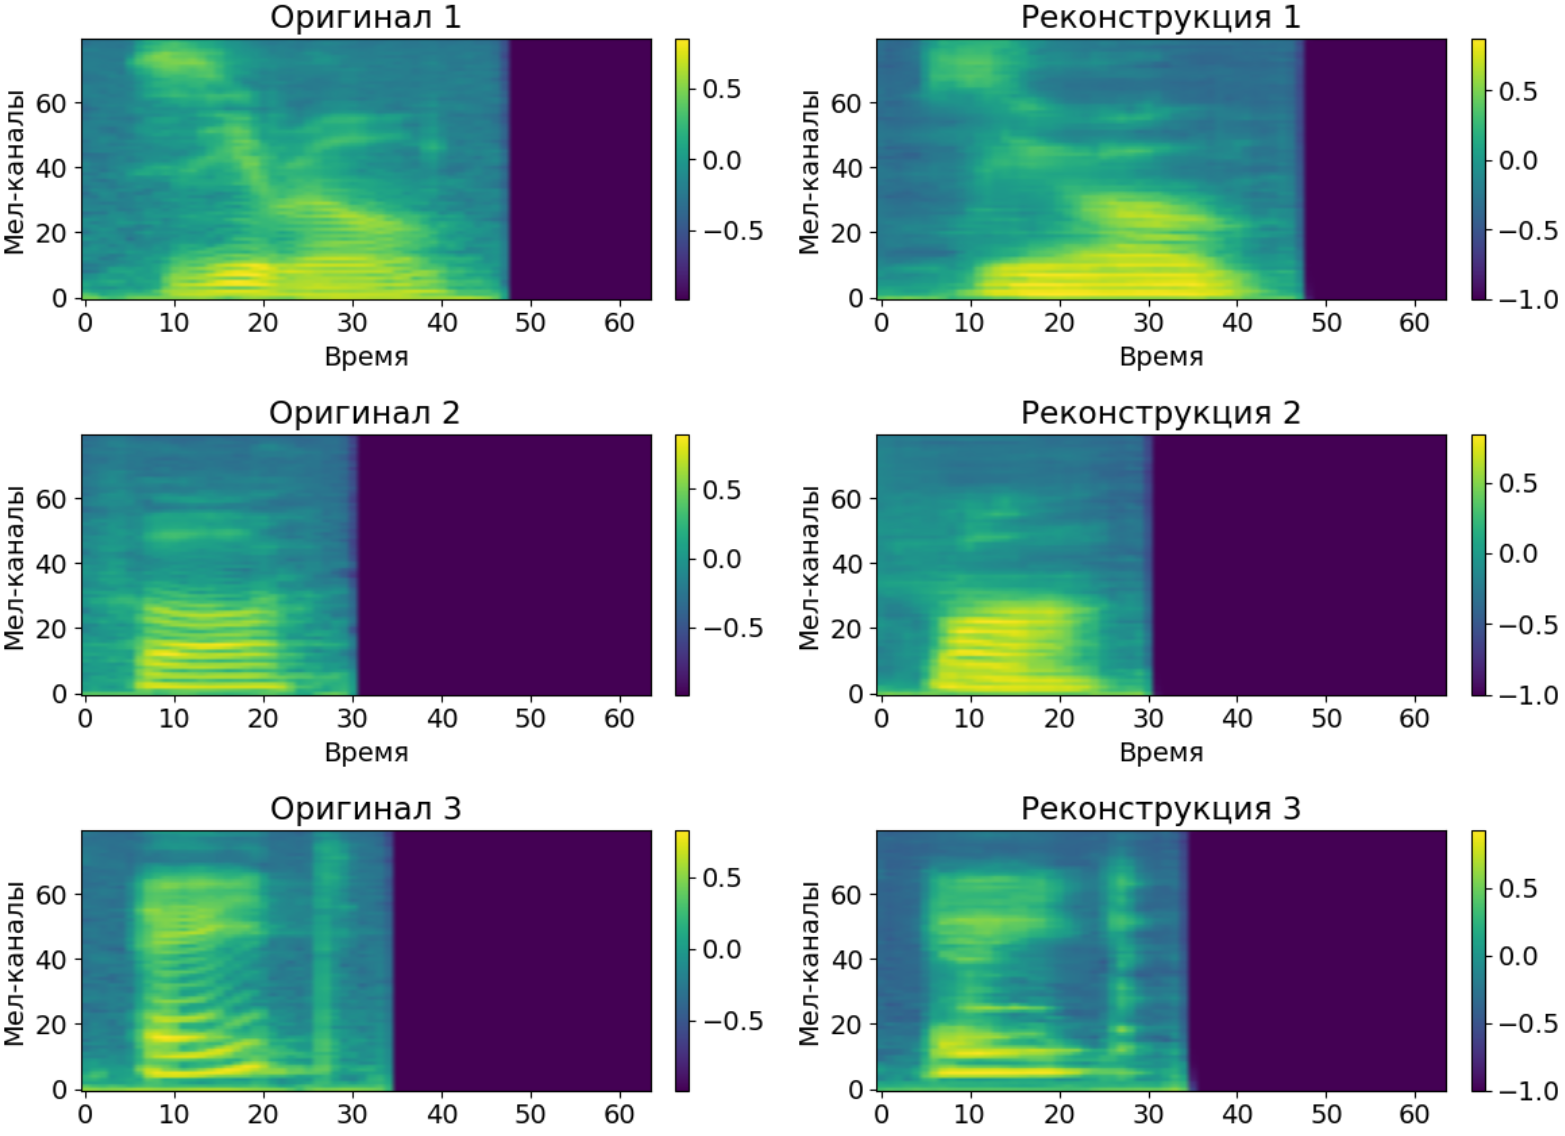

Результаты по окончании 10 эпох:


*   Critic/Generator Train Losses: -2.2557671070098877, 4.113312244415283
*   VAE/KL Valid Losses: 0.015641624405187494, 2.9952201031624






In [ ]:
save_vae(vae_model, 'vae (9).pth')
save_gan(critic, 'critic (9).pth')

from google.colab import files
files.download('vae (9).pth')
files.download('critic (9).pth')

####Comparison

In [ ]:
import torchmetrics
from torchvision import transforms

def compute_fid(vae, gan, data_loader, device='cuda'):
    vae.eval()
    gan.eval()

    fid_vae = torchmetrics.image.fid.FrechetInceptionDistance(
        feature=2048, normalize=True
    ).to(device)

    fid_gan = torchmetrics.image.fid.FrechetInceptionDistance(
        feature=2048, normalize=True
    ).to(device)

    preprocess = transforms.Compose([
        transforms.Lambda(lambda x: (x + 1) / 2),
        transforms.Lambda(lambda x: x.repeat(1, 3, 1, 1)),
        transforms.Resize((299, 299), antialias=True)
    ])


    with torch.no_grad():
        for X, _ in data_loader:
            X_spectre = create_input(X)[1]
            X_spectre = normalize_spectrogram(X_spectre, global_min, global_max)

            mu, logvar = vae.encoder(X_spectre)
            z = vae.reparameterize(mu, logvar)
            vae_recon = vae.decoder(z)

            mu, logvar = gan.encoder(X_spectre)
            z = gan.reparameterize(mu, logvar)
            gan_recon = gan.decoder(z)

            X_spectre = preprocess(X_spectre)
            vae_recon = preprocess(vae_recon)
            gan_recon = preprocess(gan_recon)

            fid_vae.update(X_spectre, real=True)
            fid_vae.update(vae_recon, real=False)

            fid_gan.update(X_spectre, real=True)
            fid_gan.update(gan_recon, real=False)

    print(f'FID VAE: {fid_vae.compute().item()}, VAE + WGAN: {fid_gan.compute().item()}')

In [ ]:
def compare_recon_spectres(vae, gan, data_loader, num_iters=5, num_samples=2):
    vae.eval()
    gan.eval()

    i = 0

    with torch.no_grad():
        for X, _ in data_loader:
            if i >= num_iters:
                break

            X_spectre = create_input(X)[1]
            X_spectre = normalize_spectrogram(X_spectre, global_min, global_max)

            #pure vae
            mu, logvar = vae.encoder(X_spectre)
            z = vae.reparameterize(mu, logvar)

            vae_recon = vae.decoder(z)

            #vae as generator
            mu, logvar = gan.encoder(X_spectre)
            z = gan.reparameterize(mu, logvar)

            generator_recon = gan.decoder(z)

            i += 1

            orig_list = X_spectre.squeeze(1).detach().cpu().numpy()
            vae_list = vae_recon.squeeze(1).detach().cpu().numpy()
            gen_list = generator_recon.squeeze(1).detach().cpu().numpy()


            fig, axes = plt.subplots(num_samples, 3, figsize=(12, 2.5 * num_samples))

            col_titles = ['Original', 'VAE Recon', 'VAE + WGAN Recon']
            for j, title in enumerate(col_titles):
                axes[0, j].set_title(title)

            for row in range(num_samples):
                img_orig = orig_list[row]
                axes[row, 0].imshow(img_orig, cmap='viridis', aspect='auto')
                axes[row, 0].axis('off')

                img_vae = vae_list[row]
                axes[row, 1].imshow(img_vae, cmap='viridis', aspect='auto')
                axes[row, 1].axis('off')

                img_gen = gen_list[row]
                axes[row, 2].imshow(img_gen, cmap='viridis', aspect='auto')
                axes[row, 2].axis('off')

            plt.tight_layout()
            plt.show()


In [ ]:
def generate_recon_audio(gan, vocoder, data_loader, save_dir, sample_rate=16000, num_samples=20):
    gan.eval()

    os.makedirs(save_dir, exist_ok=True)

    with torch.no_grad():
        for X, _ in data_loader:

            X_spectre = create_input(X)[1][:num_samples]
            X_spectre = normalize_spectrogram(X_spectre, global_min, global_max)

            mu, logvar = gan.encoder(X_spectre)
            z = gan.reparameterize(mu, logvar)

            recon = gan.decoder(z)

            recon = recon.squeeze(1).cpu()
            recon = denormalize_spectrogram(recon, global_min, global_max)
            generated_audios = vocoder.decode_batch(recon)

            for i, audio in enumerate(generated_audios):
                audio = audio.cpu().numpy()
                if audio.ndim > 1:
                    audio = audio.squeeze()

                sf.write(os.path.join(save_dir, f'sample {i}.wav'), audio, sample_rate)

            break


In [ ]:
def generate_random_spectres(vae, gan, latent_dim=64, num_iters=10, device='cuda'):
    vae.eval()
    gan.eval()



    with torch.no_grad():
        z = torch.randn(num_iters, latent_dim).to(device)

        vae_gen = vae.decoder(z)
        gan_gen = gan.decoder(z)

        vae_list = vae_gen.squeeze(1).detach().cpu().numpy()
        gan_list = gan_gen.squeeze(1).detach().cpu().numpy()


        fig, axes = plt.subplots(num_iters, 2, figsize=(12, 2.5 * num_iters))

        col_titles = ['VAE', 'VAE + WGAN']
        for j, title in enumerate(col_titles):
            axes[0, j].set_title(title)

        for row in range(num_iters):
            axes[row, 0].imshow(vae_list[row], cmap='viridis', aspect='auto')
            axes[row, 1].imshow(gan_list[row], cmap='viridis', aspect='auto')

            axes[row, 0].axis('off')
            axes[row, 1].axis('off')

        plt.tight_layout()
        plt.show()

In [ ]:
def generate_random_audio(vae_model, vocoder, latent_dim, num_samples, save_dir,
                          global_min, global_max, sample_rate=16000, device='cuda'):
    vae_model.eval()
    os.makedirs(save_dir, exist_ok=True)

    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)

        recon_spectre_norm = vae_model.decoder(z)
        recon_spectre_norm = recon_spectre_norm.squeeze(1).cpu()
        recon_spectre = denormalize_spectrogram(recon_spectre_norm, global_min, global_max)

        generated_audio = vocoder.decode_batch(recon_spectre)

        for i, audio in enumerate(generated_audio):
            audio = audio.cpu().numpy()
            if audio.ndim > 1:
                audio = audio.squeeze()

            sf.write(os.path.join(save_dir, f'sample {i}.wav'), audio, sample_rate)

In [ ]:
vae = load_vae('new_vae (7).pth').to(device)
gan = load_vae('vae (9).pth').to(device)

from speechbrain.inference.vocoders import HIFIGAN


hifi_gan = HIFIGAN.from_hparams(
    source="./pretrained_models/tts-hifigan-libritts-16kHz",
    savedir="./pretrained_models/tts-hifigan-libritts-16kHz"
)

In [ ]:
batch_size = 128

# Split by speakers
NUM_TEST_SPEAKERS = 12
full_ds = AudioMNISTDataset(root=root, augmentation=None)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
valid_ds = Subset(full_ds, valid_idxs)

valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate)

Для оценки качества генерации воспользуемся FID метрикой, но с оговоркой, что для спектрограмм это, вообще говоря, не самое идеальное решение.

In [ ]:
#FID metrcis
global_min = -11.6
global_max = 2.3
compute_fid(vae, gan, valid_loader, device='cuda')

FID VAE: 113.82456970214844, FID VAE + WGAN: 32.591148376464844.

Дообученная модель показала значительный прирост качества.

Прирост качества отчётливо заметен при визуальном сравнении спектрограмм: они стали значительно более резкими, детали лучше проработаны.
Однако модель всё ещё не полностью справляется с передачей гармонической динамики — во многих случаях гармоники реконструируются в виде горизонтальных прямых, что не присуще человеческой речи.

In [ ]:
#compare spectrograms
compare_recon_spectres(vae, gan, valid_loader, num_iters=2, num_samples=5)

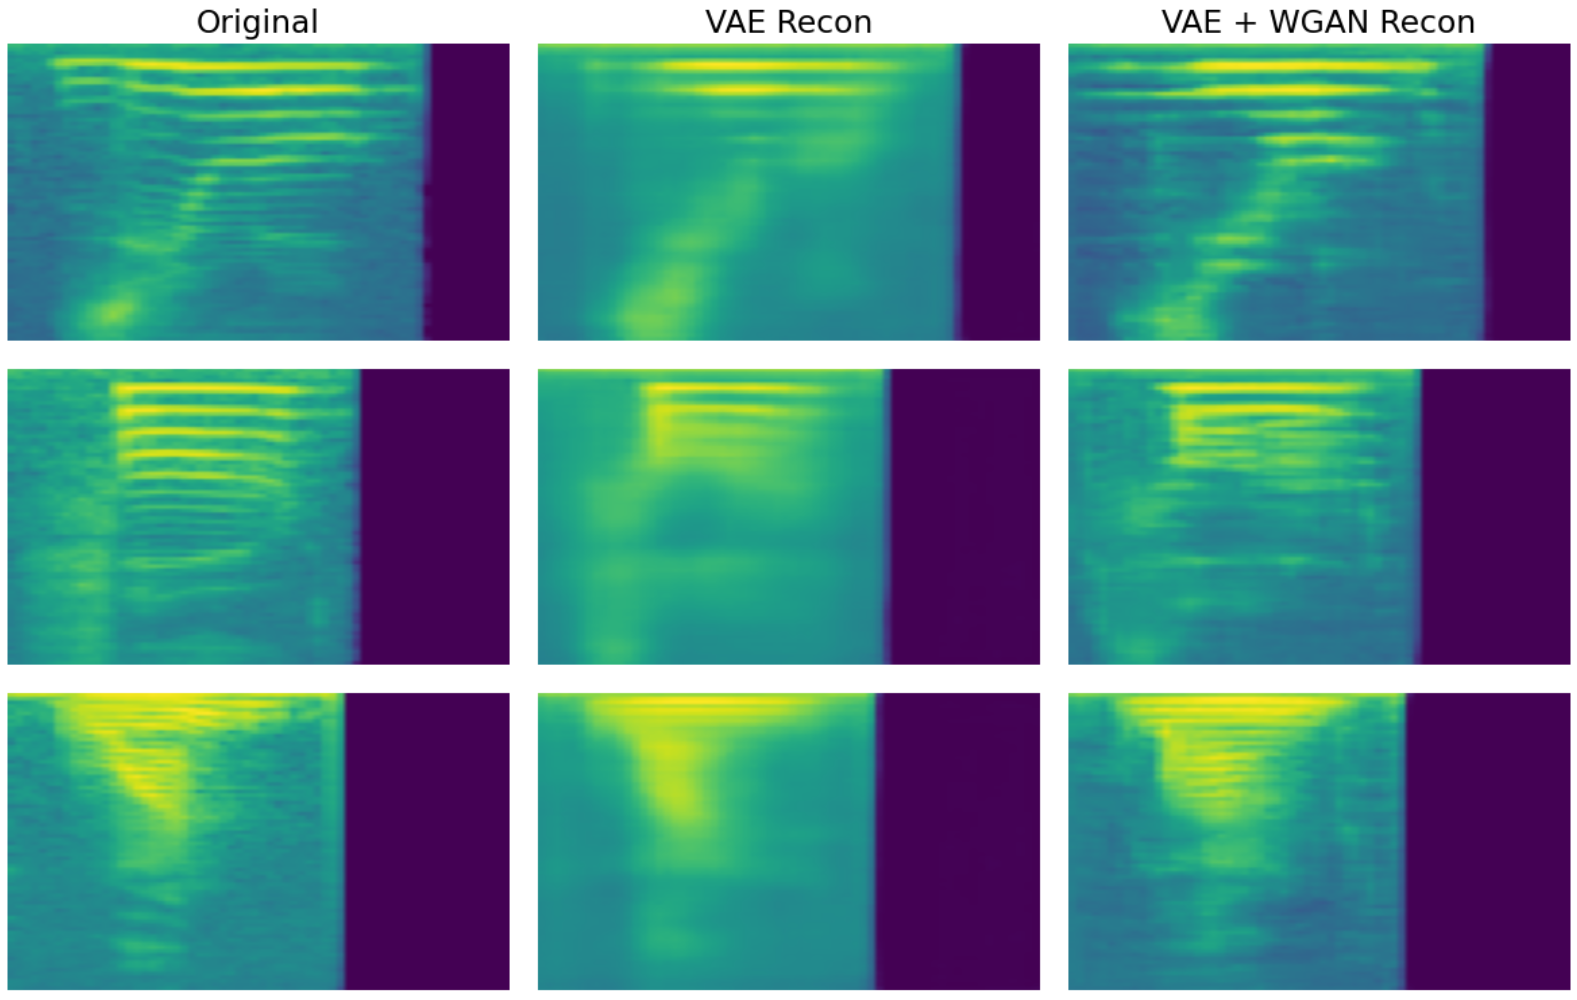

#### Генерация аудиосигнала

Далее произведем генерацию аудиосигнала с использованием обученной модели VAE+GAN в трёх режимах:

##### 1. Чистая реконструкция
Пропускаем реальную спектрограмму через энкодер, получаем латентное представление, декодируем его, затем подаем на вход в вокодер. Это позволяет оценить качество реконструкции модели.

##### 2. Генерация из стандартного нормального распределения $z \sim \mathcal{N}(0, 1)$
Берём случайный вектор из стандартного нормального распределения и подаём его на вход декодера. Так проверяется предрасположенность модели к безусловной генерации.

##### 3. Интерполяция между двумя разными аудиозаписями одной цифры
Для одной и той же цифры выбираем два аудиопримера. Получаем их скрытые представления ($μ_1$, $\logσ^2_1$) и ($μ_2$, $\logσ^2_2$) и выполняем линейную интерполяцию в пространстве параметров. Декодируем интерполированный код, чтобы услышать есть ли переход тембра.

Ознакомиться с соответствующими сгенерированными образцами можно в репозитории.

In [ ]:
#reconstruction
generate_recon_audio(gan, hifi_gan, valid_loader, 'recon_gen', sample_rate=16000, num_samples=20)

In [ ]:
#from N(0, 1); Often it sounds like some random human mumble
generate_random_audio(gan, hifi_gan, 64, 20, 'random_gen',
                          global_min, global_max, sample_rate=16000, device='cuda')

In [ ]:
def indices_by_digit(dataset: AudioMNISTDataset, digit):
    idxs = []
    for idx, (_, label, _) in enumerate(dataset.items):
        if label == digit:
            idxs.append(idx)
    return idxs

def get_two_samples_for_random_digit(dataset):
    digit = np.random.randint(0, 10)

    digit_idxs = indices_by_digit(dataset, digit)
    idx1, idx2 = np.random.choice(digit_idxs, size=2, replace=False)

    wav1, label1 = dataset[idx1]
    wav2, label2 = dataset[idx2]

    return wav1, wav2

save_dir = 'interpolated_gen'

os.makedirs(save_dir, exist_ok=True)

num_samples = 20
for i in range(num_samples):
    X1, X2 = get_two_samples_for_random_digit(full_ds)

    X1_spectre = create_input(X1)[1]
    X1_spectre = normalize_spectrogram(X1_spectre, global_min, global_max)

    X2_spectre = create_input(X2)[1]
    X2_spectre = normalize_spectrogram(X2_spectre, global_min, global_max)

    mu1, logvar1 = gan.encoder(X1_spectre)
    mu2, logvar2 = gan.encoder(X2_spectre)

    mu = 0.5 * mu1 + 0.5 * mu2
    logvar = 0.5 * logvar1 + 0.5 * logvar2
    z = gan.reparameterize(mu, logvar)

    recon = gan.decoder(z)

    # -------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(X1_spectre[0, 0].cpu().numpy(), cmap='viridis', aspect='auto')
    axes[0].set_title('Original 1')
    axes[0].axis('off')

    axes[1].imshow(recon[0, 0].detach().cpu().numpy(), cmap='viridis', aspect='auto')
    axes[1].set_title('Interpolated')
    axes[1].axis('off')

    axes[2].imshow(X2_spectre[0, 0].cpu().numpy(), cmap='viridis', aspect='auto')
    axes[2].set_title('Original 2')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
    # --------------------------------------

    recon = recon.squeeze(1).cpu()
    recon = denormalize_spectrogram(recon, global_min, global_max)
    audio = hifi_gan.decode_batch(recon)

    audio = audio.cpu().numpy()
    if audio.ndim > 1:
        audio = audio.squeeze()

    X1 = X1.squeeze()
    X2 = X2.squeeze()

    final_audio = np.concatenate([X1, audio, X2])

    sf.write(os.path.join(save_dir, f'sample {i}.wav'), final_audio, 16000)

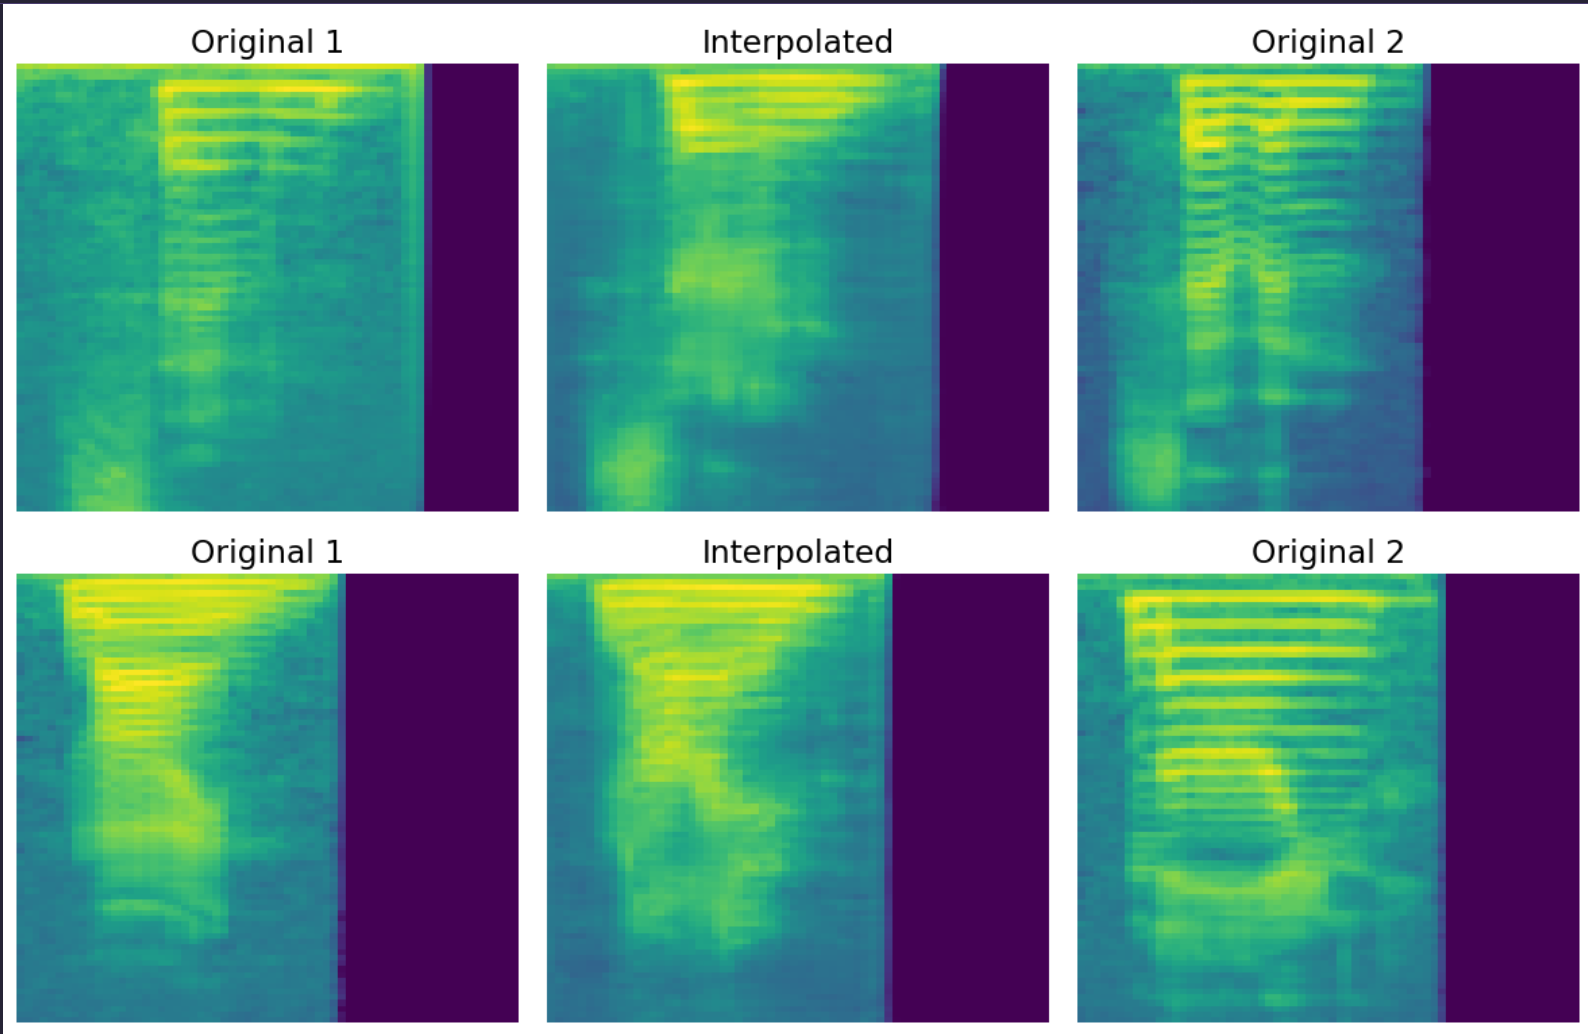

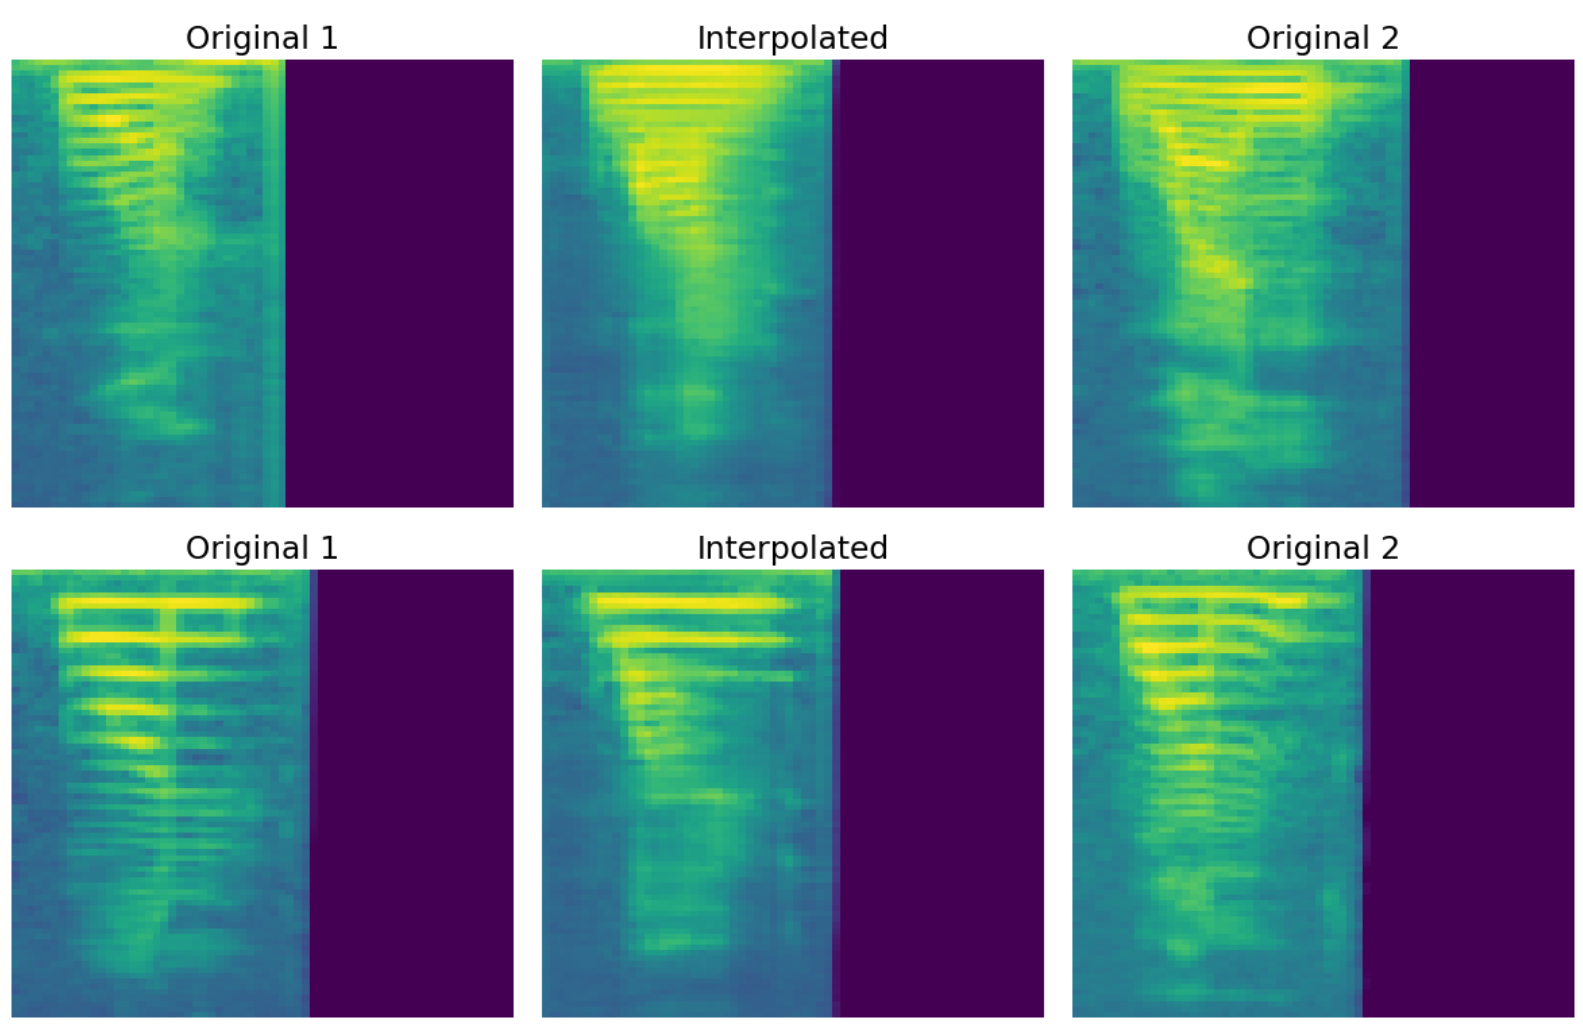

In [ ]:
import shutil
from google.colab import files

shutil.make_archive('interpolated_gen', 'zip', 'interpolated_gen')
files.download('interpolated_gen.zip')

shutil.make_archive('random_gen', 'zip', 'random_gen')
files.download('random_gen.zip')

shutil.make_archive('recon_gen', 'zip', 'recon_gen')
files.download('recon_gen.zip')

Выводы для каждого из режимов:

1. Модель хорошо справляется с задачей реконструкции мужского тембра. В восстановленном женском голосе зачастую присутствуют артефакты. Как видно из спектрограмм, модель не всегда способна уловить гармоническую динамику голоса и его экспрессивность.

2. При безусловной генерации чаще всего получаются звуки, отдалённо напоминающие человеческую речь, но порой абсолютно неразборчивые, похожие на бубнёж.

3. На спектрограммах визуально заметна способность модели к интерполяции, даже несмотря на значение `KL Loss = 2.96` на валидационном датасете. При этом интерполированный аудиосигнал не всегда получается чётким, особенно когда один из спикеров — женщина.